<h1 style="color:black;text-align:center;font-size:300%;font-family:verdana;">
DBSCAN
</h1>

# 🎬 Clustering Movies with DBSCAN

This analysis uses the **DBSCAN (Density-Based Spatial Clustering of Applications with Noise)** algorithm to uncover natural groupings in movie data from the TMDb dataset.   
Unlike k-means, DBSCAN does not require predefining the number of clusters and is well-suited for identifying arbitrarily shaped **clusters** and **outliers** (e.g., unusually short, low-rated, or high-performing movies).

## 🎯 Objective

The goal is to explore natural clusters in the movie landscape — from blockbuster hits to niche indie films — using a purely data-driven, unsupervised learning approach.

In [418]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import DBSCAN

from sklearn.preprocessing import StandardScaler

from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

from sklearn.decomposition import PCA

In [419]:
df = pd.read_csv('tmdb_movies_cleaned.csv')

In [420]:
df.head()

,id,title,runtime,release_date,budget,revenue,popularity,vote_average,vote_count,belongs_to_collection,...,main_production_country,num_production_countries,num_spoken_languages,is_english_spoken,popularity_percentile,weighted_rating,release_year,season,return_on_investment_ratio,profit_or_loss
0,5,Four Rooms,98,1995-12-09,4000000,4257354,6.0785,5.900,2687,0,...,United States of America,1,1,True,79.503667,5.915191,1995,Winter,0.064339,257354
1,6,Judgment Night,109,1993-10-15,21000000,12136938,3.1484,6.458,349,0,...,United States of America,1,1,True,52.868482,6.430314,1993,Fall,-0.422051,-8863062
2,11,Star Wars,121,1977-05-25,11000000,775398007,49.0688,8.203,21079,1,...,United States of America,1,1,True,99.688536,8.194340,1977,Spring,69.490728,764398007
3,12,Finding Nemo,100,2003-05-30,94000000,940335536,19.0085,7.816,19605,1,...,United States of America,1,1,True,98.030744,7.808617,2003,Spring,9.003570,846335536
4,13,Forrest Gump,142,1994-06-23,55000000,677387716,26.9118,8.468,28122,0,...,United States of America,1,1,True,99.035467,8.460581,1994,Summer,11.316140,622387716


In [421]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9953 entries, 0 to 9952
Data columns (total 46 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   id                          9953 non-null   int64  
 1   title                       9953 non-null   object 
 2   runtime                     9953 non-null   int64  
 3   release_date                9953 non-null   object 
 4   budget                      9953 non-null   int64  
 5   revenue                     9953 non-null   int64  
 6   popularity                  9953 non-null   float64
 7   vote_average                9953 non-null   float64
 8   vote_count                  9953 non-null   int64  
 9   belongs_to_collection       9953 non-null   int64  
 10  has_tagline                 9953 non-null   int64  
 11  has_homepage                9953 non-null   int64  
 12  num_same_title              9953 non-null   int64  
 13  changed_title               9953 

## 🔍 Feature Selection

- DBSCAN works with numerical features only.
- It clusters based on distances, so scaling is important.
- It can capture arbitrary-shaped clusters but doesn’t work well with high-dimensional - low density features.
___

In [422]:
numeric_df = df.select_dtypes(include=['int64', 'float64'])
print(numeric_df.columns.tolist())

['id', 'runtime', 'budget', 'revenue', 'popularity', 'vote_average', 'vote_count', 'belongs_to_collection', 'has_tagline', 'has_homepage', 'num_same_title', 'num_genres', 'num_production_companies', 'num_production_countries', 'num_spoken_languages', 'popularity_percentile', 'weighted_rating', 'release_year', 'return_on_investment_ratio', 'profit_or_loss']


In [423]:
bool_df = df.select_dtypes(include=['bool'])
print(bool_df.columns.tolist())

['changed_title', 'Comedy', 'Action', 'Animation', 'Drama', 'History', 'Family', 'War', 'Thriller', 'Crime', 'Adventure', 'Music', 'Fantasy', 'Science Fiction', 'TV Movie', 'Western', 'Documentary', 'Romance', 'Mystery', 'Horror', 'top10_prod_comps', 'is_english_spoken']


### Due to DBSCAN being highly sensetive to distance metrics, boolean features (consisting of only 0 or 1 values) are not the best candidates for quality clustering with this algorithm.
* Note - We can use these features if we handle them correctly: adjust the distance matrix (euclidean can make all points seem equally distant) and normalize the numeric features to scale from 0 to 1,  
but due to the fact that we have so many features to chose from, we have decided not to currently use these features.

In [424]:
# drop non-relevant and bool columns
numeric_df = numeric_df.drop(columns=['id', 'belongs_to_collection', 'has_tagline', 'has_homepage'])
print(f"Number of numeric features after dropping non-relevant columns: {numeric_df.shape[1]}")

Number of numeric features after dropping non-relevant columns: 16


In [425]:
numeric_df.columns

Index(['runtime', 'budget', 'revenue', 'popularity', 'vote_average',
       'vote_count', 'num_same_title', 'num_genres',
       'num_production_companies', 'num_production_countries',
       'num_spoken_languages', 'popularity_percentile', 'weighted_rating',
       'release_year', 'return_on_investment_ratio', 'profit_or_loss'],
      dtype='object')

## 📁 Organizing Relevant Data
1. Highly Correlated Features Cause Redundancy:
   - Features that are strongly correlated don't add new information, however they do **distort distance calculations**, since their impact is calculated **twice**.
   - This can lead to DBSCAN clustering based on those features alone, ignoring others.
   - Fix: We can keep just one of any strongly correlated pair - even better if we have a feature that consists of both.
2. Highly Skewed Features Dominate Distance:
   - Extremely skewed features can **introduce outliers** or **compress distances** between points even after scalling.
   - This can cause inconsistent clusters or classify everything as noise.
   - Fix: Use log transforms or percentiles to even skewness or drop overly skewed features if they don't help with cluster seperation.
___


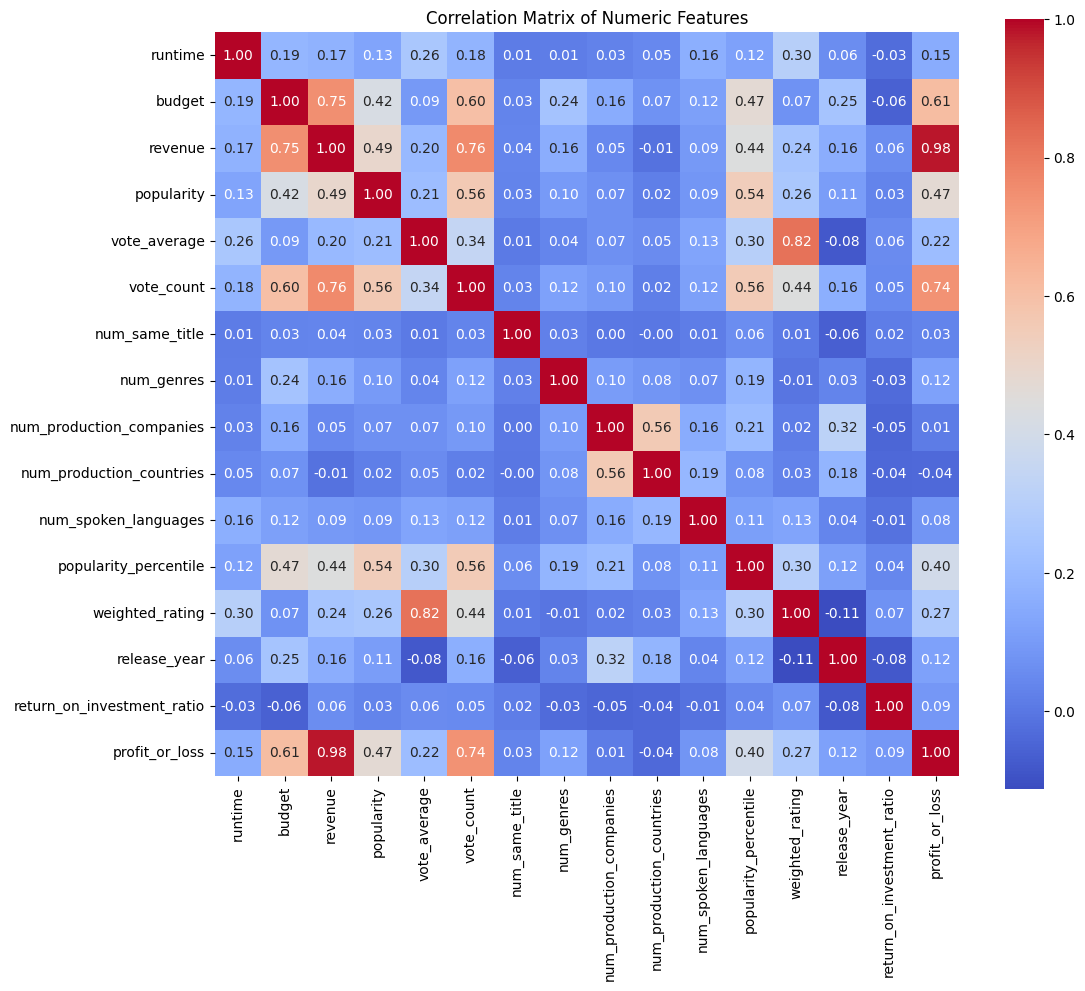

In [426]:
numeric_correlation = numeric_df.corr()
plt.figure(figsize=(12, 10))
sns.heatmap(numeric_correlation, annot=True, fmt=".2f", cmap='coolwarm', square=True)
plt.title('Correlation Matrix of Numeric Features')
plt.show()

In [427]:
numeric_skewness = numeric_df.skew().sort_values(ascending=True)
print("Skewness of numeric features:")
print(numeric_skewness.round(2))

Skewness of numeric features:
release_year                  -1.66
vote_average                  -0.64
popularity_percentile          0.00
weighted_rating                0.22
num_genres                     0.49
runtime                        1.13
num_production_companies       1.86
num_spoken_languages           2.73
num_production_countries       3.04
budget                         3.40
vote_count                     4.05
num_same_title                 5.10
revenue                        6.02
profit_or_loss                 6.69
popularity                    19.62
return_on_investment_ratio    22.29
dtype: float64


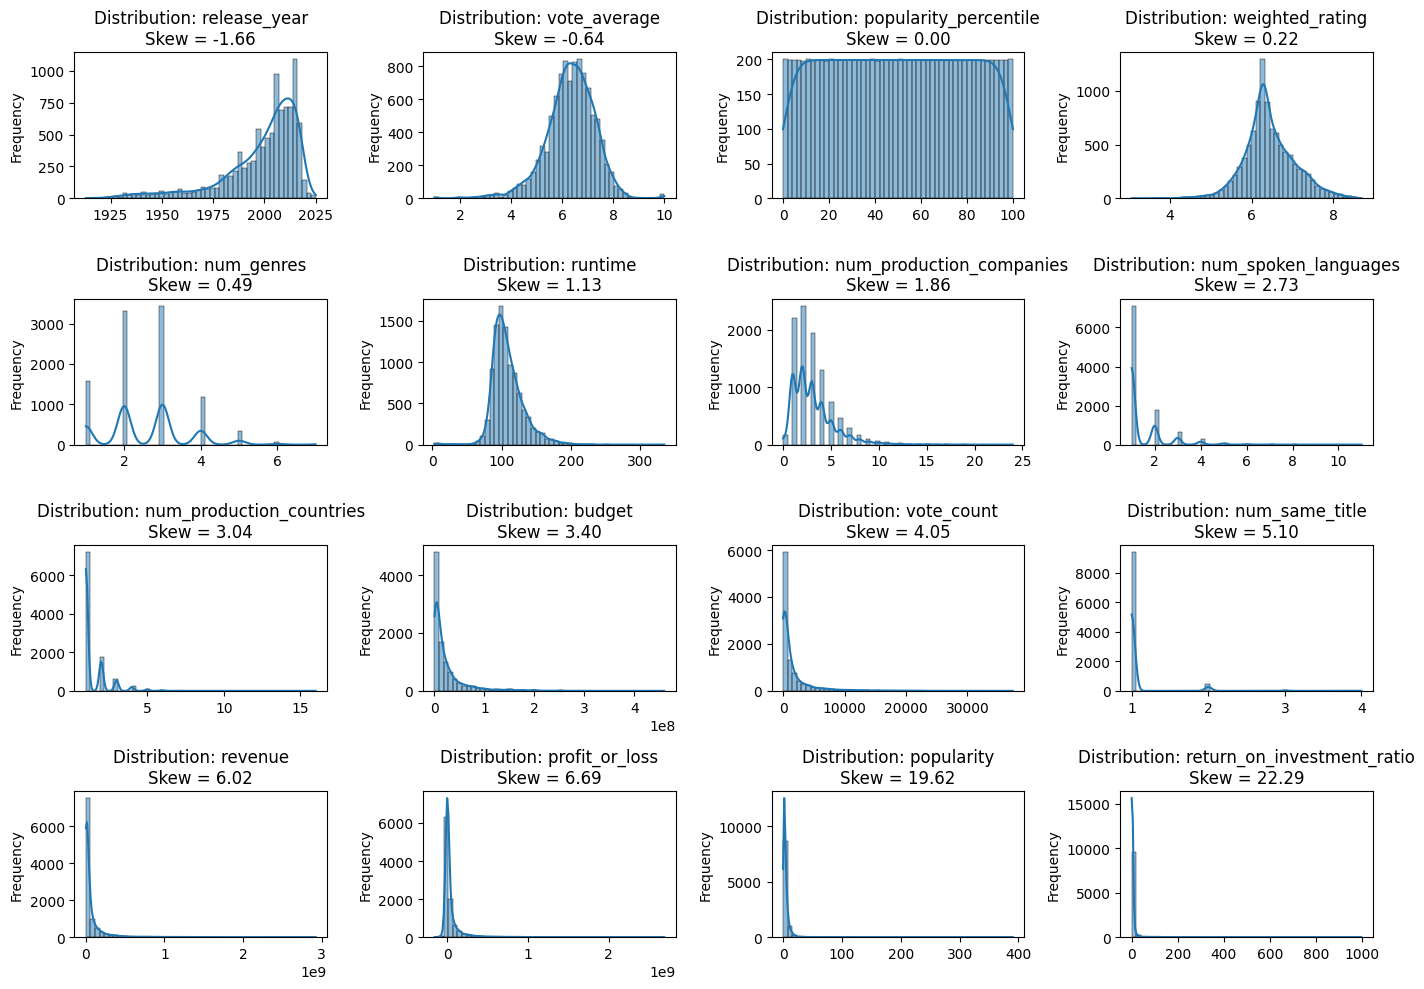

In [428]:
plt.figure(figsize=(14, 10))
for i, feature in enumerate(numeric_skewness.index[:16]):
    plt.subplot(4, 4, i+1)
    sns.histplot(df[feature], bins=50, kde=True)
    plt.title(f'Distribution: {feature}\nSkew = {numeric_skewness[feature]:.2f}')
    plt.xlabel('')
    plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

### `budget` and `revenue` are both highly correlated and skewed, meaning that if used together they double count financial size without normalizing success.
We will test to see how they cluster seperetly and check if they uncover any hidden patterns:

In [429]:
df['log_budget'] = np.log(df['budget'])
df['log_revenue'] = np.log(df['revenue'])

In [430]:
X = df[['log_budget', 'log_revenue']]

In [431]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [432]:
dbscan = DBSCAN(eps=0.5, min_samples=10)
df['cluster'] = dbscan.fit_predict(X_scaled)

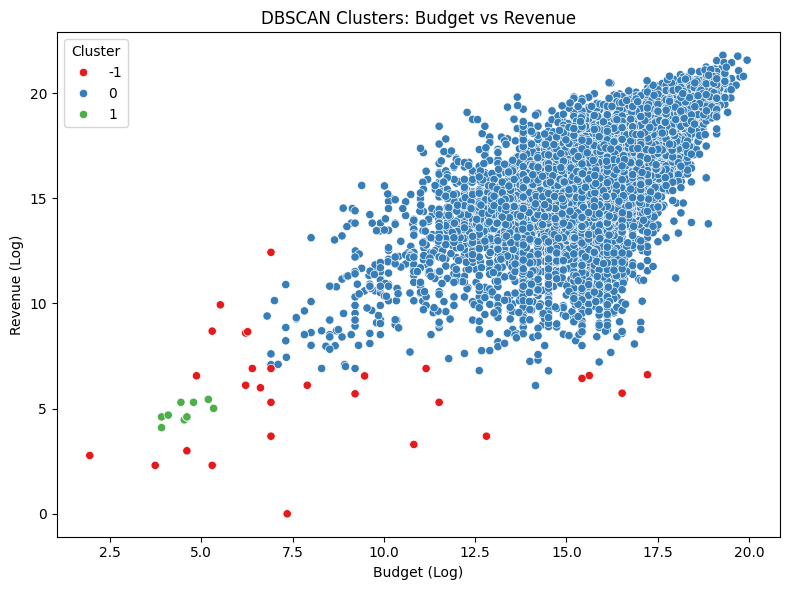

cluster
 0    9914
-1      28
 1      11
Name: count, dtype: int64


In [433]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x=X['log_budget'], y=X['log_revenue'], hue=df['cluster'], palette='Set1', legend='full')
plt.title('DBSCAN Clusters: Budget vs Revenue')
plt.xlabel('Budget (Log)')
plt.ylabel('Revenue (Log)')
plt.legend(title='Cluster')
plt.tight_layout()
plt.show()

print(df['cluster'].value_counts())

### 💡 Reminder: points considered outliers are classified as -1

In [434]:
valid_clusters = df[df["cluster"] != -1]  # Keep only clustered points - Remove noise
X_valid = X_scaled[df["cluster"] != -1]  # Match the filtered dataset

### 🎯 The best suited evaluation metric for DBSCAN is the `Davies-Boulding Index`
- This metric evaluates intra-cluster similarity and inter-cluster differences to give us a score between 0 and ∞.
- The lower the score (closer to 0) the more well-seperated our clusters are.
- Due to it being sensetive to cluster density and shape, it is best tailored to evaluate DBSCAN.

In [435]:
db_score = davies_bouldin_score(X_valid, valid_clusters["cluster"])
print(f"Davies-Bouldin Index: {db_score:.3f}")

Davies-Bouldin Index: 0.187


### 🤔 Initial Clustering Thoughts
- For the initial metrics of epsilon = 0.5 and minimum samples = 10, we gather only 2 clusters.
- These clusters are well seperated and greatly compact - as seen both in the plot and with the very low DB-Score.
- We barely learn any hidden patterns due to one cluster being very large (most of the data) and the other being very small.
- We can only infer that the smaller cluster are movies with fairly low budgets that paid-off the investment without making any real profit.
- Outliers may represent movies that either made a good profit or suffered a substantial loss.
   
We will test different epsilon metric to see how this effects the clusters:

In [436]:
dbscan = DBSCAN(eps=0.2, min_samples=10)
df['cluster'] = dbscan.fit_predict(X_scaled)

In [437]:
valid_clusters = df[df["cluster"] != -1]
X_valid = X_scaled[df["cluster"] != -1]

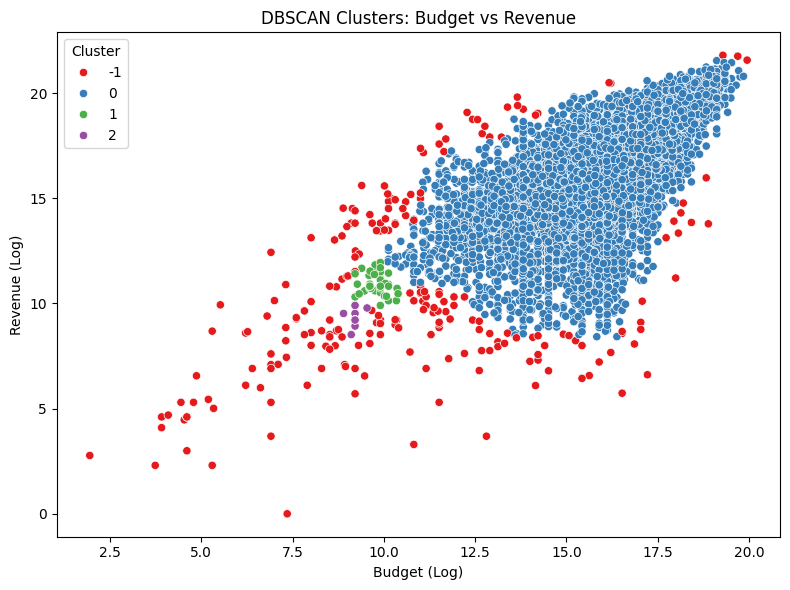

cluster
 0    9667
-1     224
 1      38
 2      24
Name: count, dtype: int64


In [438]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x=X['log_budget'], y=X['log_revenue'], hue=df['cluster'], palette='Set1', legend='full')
plt.title('DBSCAN Clusters: Budget vs Revenue')
plt.xlabel('Budget (Log)')
plt.ylabel('Revenue (Log)')
plt.legend(title='Cluster')
plt.tight_layout()
plt.show()

print(df['cluster'].value_counts())

In [439]:
db_score = davies_bouldin_score(X_valid, valid_clusters["cluster"])
print(f"Davies-Bouldin Index: {db_score:.3f}")

Davies-Bouldin Index: 0.432


### 🤔 Secondary Clustering Thoughts
- For the secondary metrics of epsilon = 0.2 and minimum samples = 10, we gained another cluster.
- These clusters are still well seperated and greatly compact but a bit less so then before - higher DB-Score.
- Again it is hard to conclude any hidden patterns.
   
Both `budget` and `revenue` correlate highly with the `profit_or_loss` feature and due this variable being an expression of both (budget - revenue), we will 'represent' them using only that feature.

In [440]:
numeric_df = numeric_df.drop(columns=['budget', 'revenue'])

___
### We will continue to test different features:  
`vote_count`, `vote_average` and `runtime` could raise some interesting insights.  

❗ `vote_count` is very highly skewed so we will need to log transform it.

In [441]:
df['log_vote_count'] = np.log1p(df['vote_count'])

In [553]:
X = df[['log_vote_count', 'vote_average', 'runtime']]

In [554]:
X_scaled = scaler.fit_transform(X)

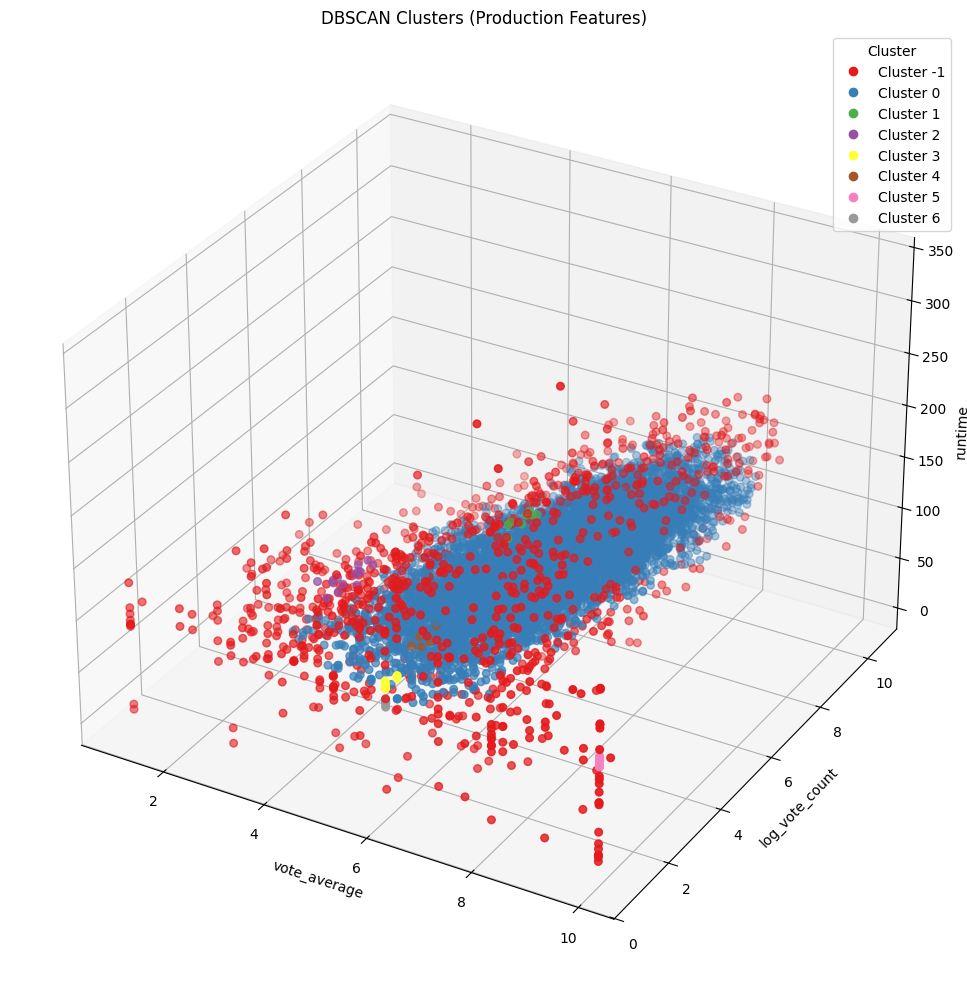

cluster
 0    8922
-1     980
 2      14
 3      10
 1       8
 5       8
 6       6
 4       5
Name: count, dtype: int64


In [555]:
dbscan = DBSCAN(eps=0.3, min_samples=8)
df['cluster'] = dbscan.fit_predict(X_scaled)

x = df['vote_average']
y = df['log_vote_count']
z = df['runtime']
labels = df['cluster']

# Set up 3D plot
fig = plt.figure(figsize=(12, 10))
ax = fig.add_subplot(111, projection='3d')

# Scatter plot with cluster hue
scatter = ax.scatter(x, y, z, c=labels, cmap='Set1', s=30)

# Axis labels
ax.set_title('DBSCAN Clusters (Production Features)')
ax.set_xlabel('vote_average')
ax.set_ylabel('log_vote_count')
ax.set_zlabel('runtime')

# Add legend with unique labels
handles, _ = scatter.legend_elements(prop="colors")
cluster_labels = [f'Cluster {label}' for label in sorted(df['cluster'].unique())]
ax.legend(handles, cluster_labels, title="Cluster", loc='upper right')

plt.tight_layout()
plt.show()

# Print cluster counts
print(df['cluster'].value_counts())

### ❓ It is quite challenging to understand the 3D graph but we have options to make insights a bit clearer:
- We can either use PCA or t-SNE to reduce the dimensions to a 2D graph.
- Or we can use the `weighted_rating` feature that consists of both the `vote_average` and the `vote_count` in it's formula.

In [544]:
X = df[['weighted_rating', 'runtime']]

In [545]:
X_scaled = scaler.fit_transform(X)

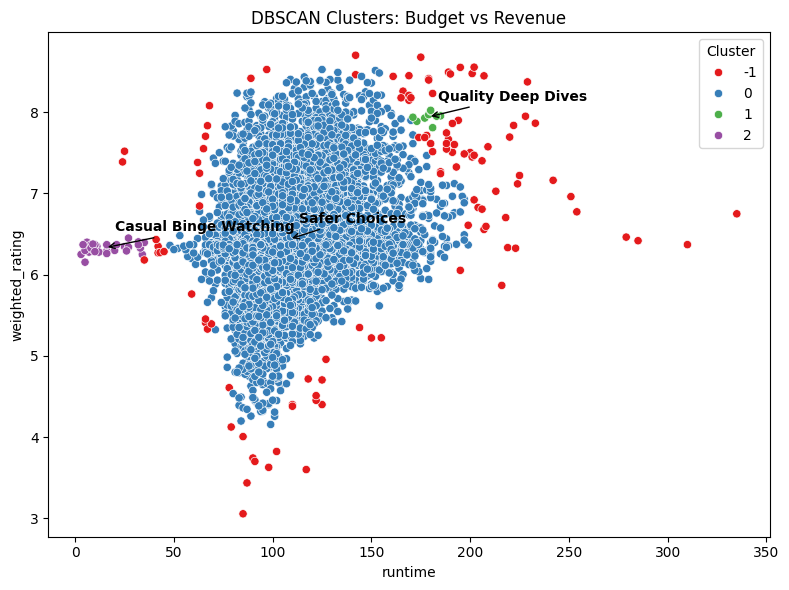

cluster
 0    9800
-1     110
 2      34
 1       9
Name: count, dtype: int64


In [552]:
dbscan = DBSCAN(eps=0.3, min_samples=8)
df['cluster'] = dbscan.fit_predict(X_scaled)

plt.figure(figsize=(8, 6))
sns.scatterplot(x=X['runtime'], y=X['weighted_rating'], hue=df['cluster'], palette='Set1', legend='full')
plt.title('DBSCAN Clusters: Budget vs Revenue')
plt.xlabel('runtime')
plt.ylabel('weighted_rating')
plt.legend(title='Cluster')
plt.tight_layout()


custom_labels = {
    0: "Safer Choices",
    1: "Quality Deep Dives",
    2: "Casual Binge Watching",
}
for cluster_id, label in custom_labels.items():
    if cluster_id not in df['cluster'].unique(): # Skip outlier 'group'
        continue
    cluster_data = df[df['cluster'] == cluster_id]
    center_x = cluster_data['runtime'].mean()
    center_y = cluster_data['weighted_rating'].mean()
    plt.annotate(label,
                 xy=(center_x, center_y),
                 xytext=(center_x + 5, center_y + 0.2),
                 arrowprops=dict(facecolor='black', arrowstyle='->', lw=1),
                 fontsize=10,
                 fontweight='bold',
                 ha='left')

plt.show()

print(df['cluster'].value_counts())

### 💡 After manually testing different combinations of epsilon and minimum values, we gain categorical insights:
- Casual Binge Watching - Movies up to around 50 minutes with average ratings; pass the time movies.
- Safer Choices - Movies of average length with a range of ok ratings; can't go wrong with these.
- Quality Deep Dives - Fairly long movies with high ratings; if you have time to invest in a good watch.

___
### We will continue to test different features:  
We would like to see how the different movie `genres` cluster together. 

❗ This will be challenging seeing as there are 19 different genres (columns) - need of dimensionality reduction (we will use PCA).  
❗ Each genre is a binary feature, further making it difficult to interpret (not enough varied info from each feature).  
❗ It will probably not be enformative enough to gain any real conclusions but we will still procceed to check.

In [ ]:
print(bool_df.columns.tolist())

['changed_title', 'Comedy', 'Action', 'Animation', 'Drama', 'History', 'Family', 'War', 'Thriller', 'Crime', 'Adventure', 'Music', 'Fantasy', 'Science Fiction', 'TV Movie', 'Western', 'Documentary', 'Romance', 'Mystery', 'Horror', 'top10_prod_comps', 'is_english_spoken']


In [ ]:
X = bool_df.drop(columns=['changed_title', 'top10_prod_comps', 'is_english_spoken'])

In [460]:
X_scaled = scaler.fit_transform(X)

### ⏬ PCA - Principal Component Analysis:
- We "trade" information for reduced dimensions.
- The variance ratio will show us how much explained variance we keep when reducing to 'n' components (dimensions).
- We can see how each feature "contributes" to each dimension (after reduction) using either a weighted feature graph or use creative arrows (biplot-style loadings).

### 👍 Rule of Thumb - we should save at least 70-80% of the info variance.

In [461]:
pca = PCA()
pca.fit(X_scaled)

PCA()

In [453]:
pca.explained_variance_ratio_

array([0.12247887, 0.10969036, 0.07990978, 0.06711589, 0.06542673,
       0.05874519, 0.05389689, 0.05232102, 0.05066398, 0.04677809,
       0.04430905, 0.04238245, 0.03923375, 0.03659542, 0.03335441,
       0.02846003, 0.02624514, 0.02338951, 0.01900343])

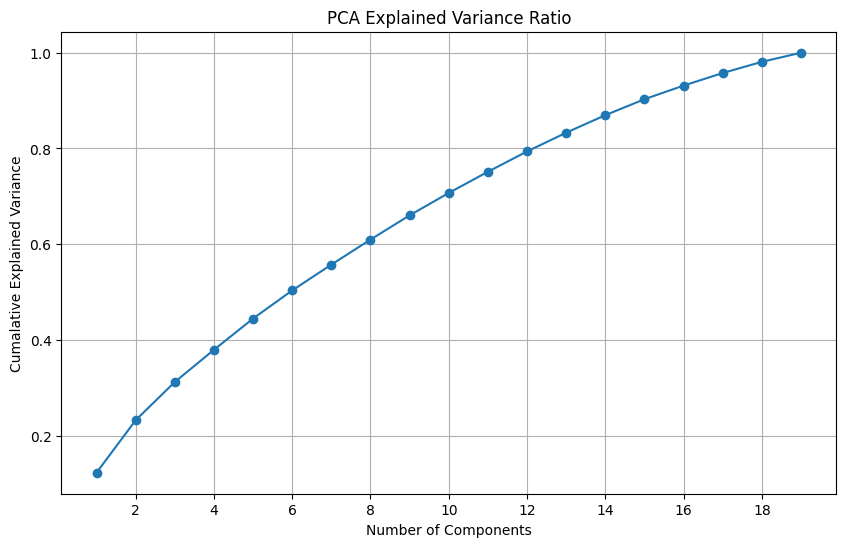

In [464]:
plt.figure(figsize=(10, 6))
plt.plot(range(1,20), pca.explained_variance_ratio_.cumsum(), marker='o')
plt.xticks(range(2, 20, 2))
plt.title('PCA Explained Variance Ratio')
plt.xlabel('Number of Components')
plt.ylabel('Cumalative Explained Variance')
plt.grid(True)
plt.show()

## ❗ Very low info variance is kept at visually explainable dimensions (1/2/3).
   - ❌ We won't be able to come to any real statistical conclusions with this because they only covers around 20-30% of the actual information. 
   - ❌ We can only use this to spot broad patterns, clusters and outliers.

In [493]:
# testing with 3 components ~ 30% explained variance
pca = PCA(n_components=3)
scores_pca = pca.fit_transform(X_scaled)

In [494]:
pca.explained_variance_ratio_

array([0.12247887, 0.10969036, 0.07990978])

In [495]:
dbscan = DBSCAN(eps=0.5, min_samples=5)
labels = dbscan.fit_predict(scores_pca)

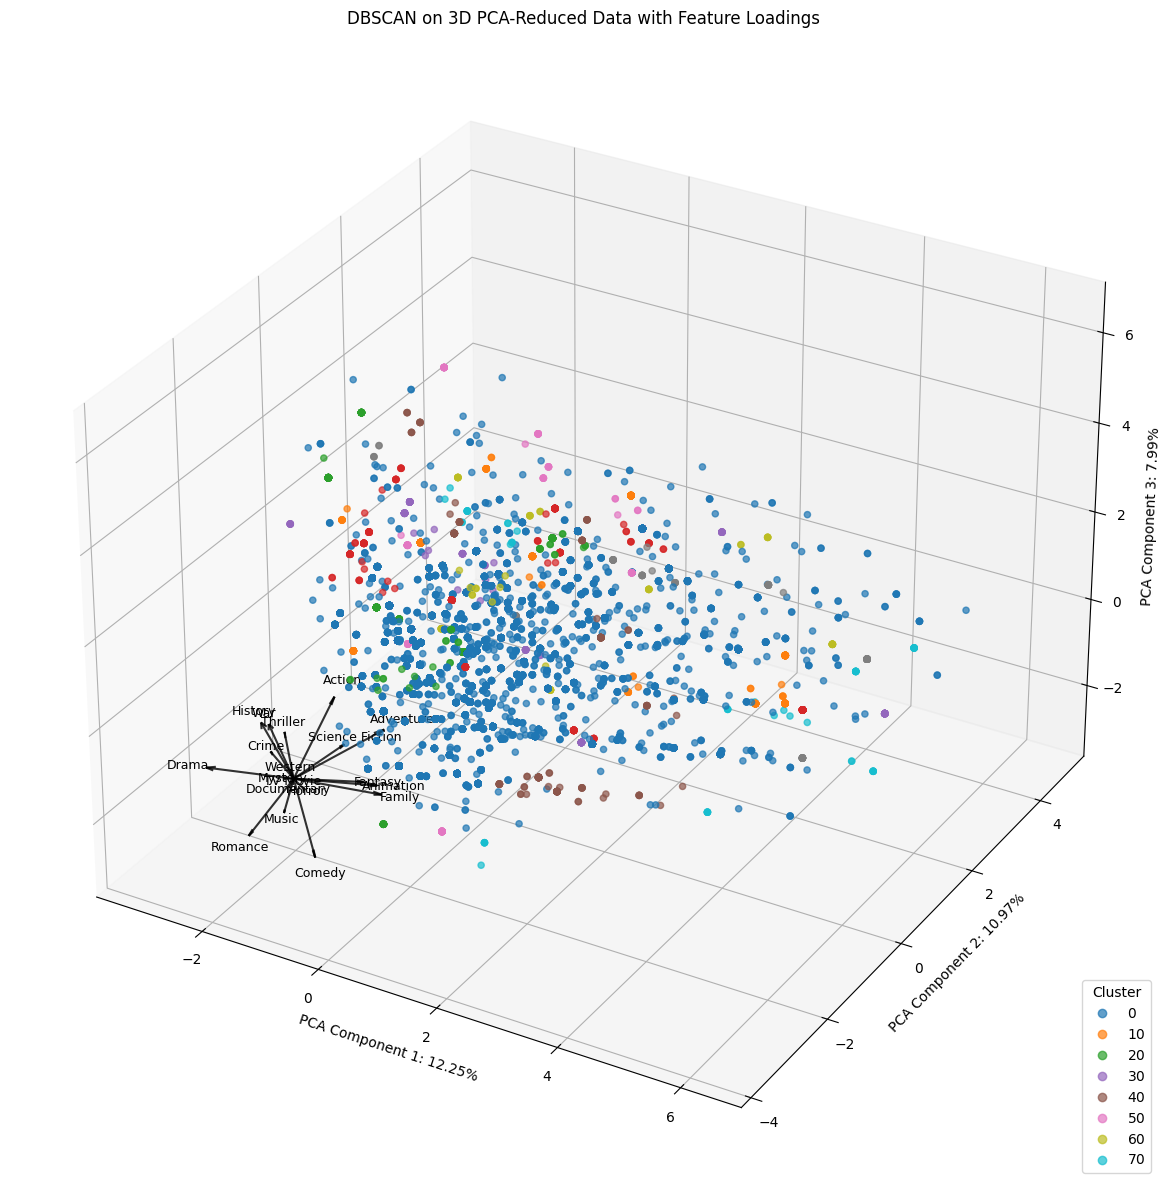

In [498]:
fig = plt.figure(figsize=(12, 12))
ax = fig.add_subplot(111, projection='3d')
scatter = ax.scatter(scores_pca[:, 0], scores_pca[:, 1], scores_pca[:, 2],
                     c=labels, cmap='tab10', alpha=0.7)

ax.set_xlabel(f'PCA Component 1: {pca.explained_variance_ratio_[0] * 100:.2f}%')
ax.set_ylabel(f'PCA Component 2: {pca.explained_variance_ratio_[1] * 100:.2f}%')
ax.set_zlabel(f'PCA Component 3: {pca.explained_variance_ratio_[2] * 100:.2f}%')
ax.set_title('DBSCAN on 3D PCA-Reduced Data with Feature Loadings')
ax.legend(*scatter.legend_elements(), title="Cluster", loc='lower right')

# Offset origin
offset = -2
arrow_size = 3
feature_names = X.columns

# Draw arrows from offset point
for i in range(pca.components_.shape[1]):
    ax.quiver(offset, offset, offset,
              pca.components_[0, i] * arrow_size,
              pca.components_[1, i] * arrow_size,
              pca.components_[2, i] * arrow_size,
              color='black', arrow_length_ratio=0.1, alpha=0.8)

    ax.text(offset + pca.components_[0, i] * arrow_size * 1.2,
            offset + pca.components_[1, i] * arrow_size * 1.2,
            offset + pca.components_[2, i] * arrow_size * 1.2,
            feature_names[i],
            color='black', fontsize=9, ha='center', va='center')

plt.tight_layout()
plt.show()

In [499]:
# testing with 2 components ~ 20% explained variance
pca = PCA(n_components=2)
scores_pca = pca.fit_transform(X_scaled)

In [500]:
pca.explained_variance_ratio_

array([0.12247887, 0.10969036])

In [501]:
dbscan = DBSCAN(eps=0.5, min_samples=5)
labels = dbscan.fit_predict(scores_pca)

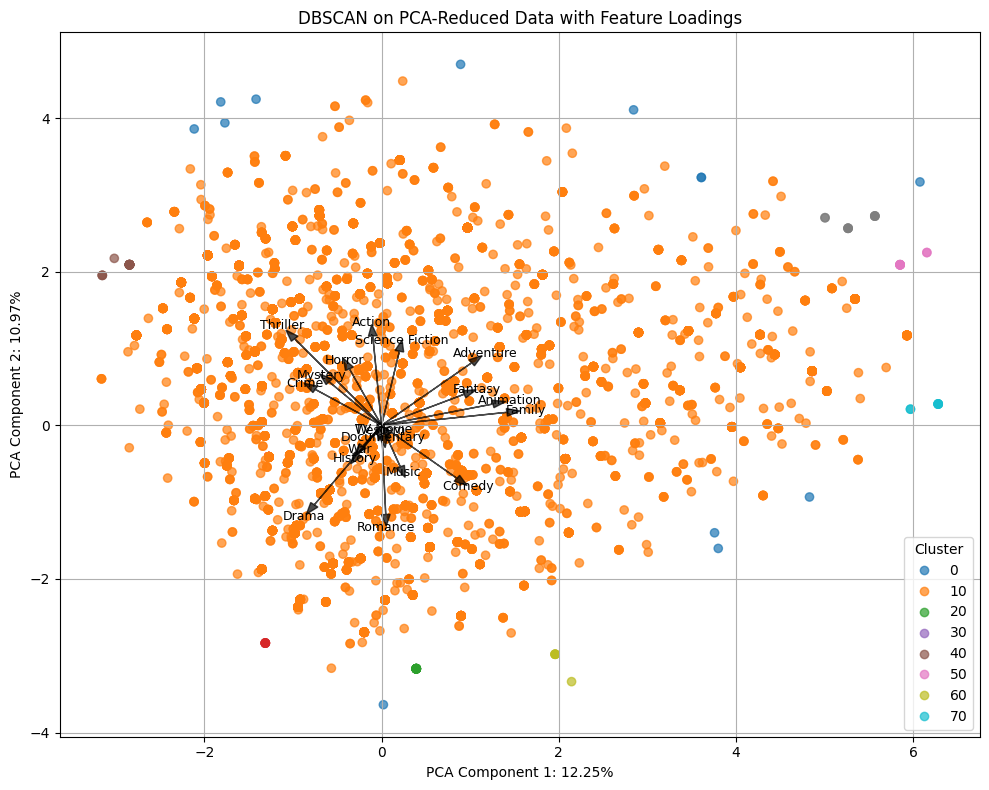

In [502]:
plt.figure(figsize=(10, 8))
plt.scatter(scores_pca[:, 0], scores_pca[:, 1], c=labels, cmap='tab10', alpha=0.7)
plt.xlabel(f'PCA Component 1: {pca.explained_variance_ratio_[0] * 100:.2f}%')
plt.ylabel(f'PCA Component 2: {pca.explained_variance_ratio_[1] * 100:.2f}%')
plt.title('DBSCAN on PCA-Reduced Data with Feature Loadings')
plt.legend(*scatter.legend_elements(), title="Cluster", loc='lower right')
plt.grid(True)

# Add PCA component vectors ("arrows")
arrow_size = 3  
feature_names = X.columns 
for i in range(pca.components_.shape[1]):
    plt.arrow(0, 0,
              pca.components_[0, i] * arrow_size,
              pca.components_[1, i] * arrow_size,
              color='black', alpha=0.7, head_width=0.1)
    plt.text(pca.components_[0, i] * arrow_size * 1.15,
             pca.components_[1, i] * arrow_size * 1.15,
             feature_names[i],
             color='black', ha='center', va='center', fontsize=9)

plt.tight_layout()
plt.show()

### ⏬ t-SNE - t-distributed Stochastic Neighbor Embedding:
- Unlike PCA, t-SNE is a non-linear technique that focuses on keeping the local structure of the data - points that are close in high dimension will stay close in low dimensions.
- Uses a t-distribution to model the probability of points being neighbors.
- A key parameter in t-SNE is `perplexity`, which controls the number of nearest neighbors considered when calculating the probability distributions:  
    * A lower perplexity focuses on local structure.  
    * A higher perplexity considers more global relationships.

### 🫡 t-SNE tends to pair better with DBSCAN since both focus on preserving local neighborhood structure and density-based relationships.
### 🚨 Important Note - t-SNE is not ment to interpret feature contibution but rather visualize how the data is structured.

In [ ]:
from sklearn.manifold import TSNE

tsne = TSNE(n_components=3, perplexity=30, random_state=42)
X_tsne = tsne.fit_transform(X_scaled)

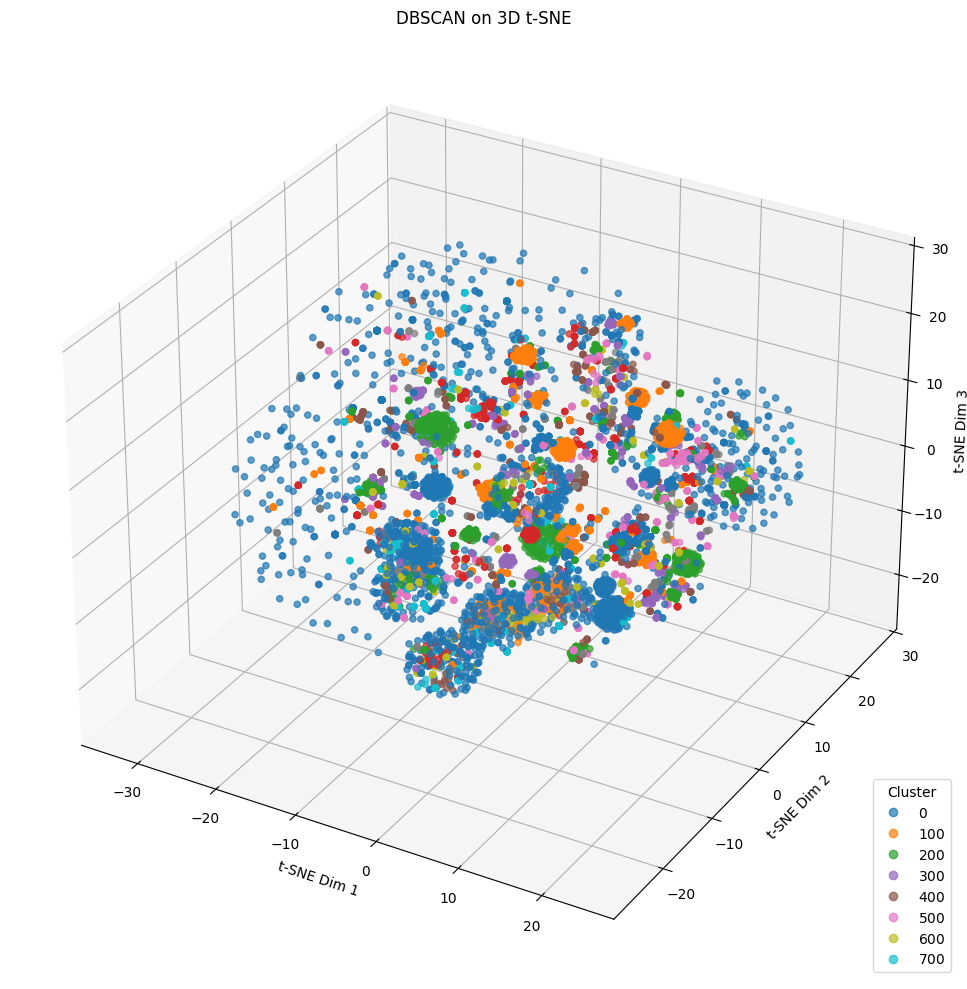

In [543]:
dbscan = DBSCAN(eps=0.9, min_samples=3)
labels = dbscan.fit_predict(X_tsne)

fig = plt.figure(figsize=(12, 10))
ax = fig.add_subplot(111, projection='3d')
scatter = ax.scatter(X_tsne[:, 0], X_tsne[:, 1], X_tsne[:, 2],
                     c=labels, cmap='tab10', alpha=0.7)

ax.set_xlabel('t-SNE Dim 1')
ax.set_ylabel('t-SNE Dim 2')
ax.set_zlabel('t-SNE Dim 3')
ax.set_title('DBSCAN on 3D t-SNE')
ax.legend(*scatter.legend_elements(), title="Cluster", loc='lower right')
plt.tight_layout()
plt.show()

### 💡 After manually testing different combinations of epsilon and minimum values, we can see patterns in the data:
- We can see round structers of data form, probably representing each individual genre.
- Different clusters may represent common genre combinations.
- The main cluster (0) dominates the space, which could mean that it's points are densely packed in high-dimensional space but not distinctive enough to be separated into meaningful clusters by DBSCAN.

___
### We will continue to test different features:  
`num_production_companies`, `num_production_countries` and `num_spoken_languages` could raise some interesting insights.  

❗ All 3 features are highly skewed and so we will need to log transform them.  
❗ Because `num_production_companies`, `num_production_countries` are fairly correlated, their distances maybe biased - pay attention.  
❗ `num_production_companies` can have a value of 0.

Due to one feature having a value of 0, regular log transform won't work.  
We will need to use log1p() which does log (x + 1).  
To keep consistency, we will use log1p() on all 3 features even though there is a difference between it and regular log for large values but it is minor. 

In [489]:
df['log_num_production_companies'] = np.log1p(df['num_production_companies'])
df['log_num_production_countries'] = np.log1p(df['num_production_countries'])
df['log_num_spoken_languages'] = np.log1p(df['num_spoken_languages'])